# 3-A1 作業：加密貨幣價格分析（解答）

[![在 Colab 開啟](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/finlab-python/hahow-crypto-course/blob/main/3-A1_price_analysis_solution.ipynb)

**對應影片**：第 3 章 作業 3-A1【Python 基礎教學】加密貨幣價格分析

**和影片的差異**

- 資料改由新版 finlab_crypto 下載（Binance 公開資料端點，不需金鑰）。
- pandas 2 的頻率代號改為 `'ME'`（月底）與 `'YE'`（年底），取代舊的 `'M'`、`'Y'`。
- 「近 100 日最高價格」改用 high 欄位（舊解答誤用 low）。

In [1]:
%pip install -q finlab_crypto==0.3.0

Note: you may need to restart the kernel to use updated packages.


## 下載 BTC、ETH、BNB 的日 K 線

In [2]:
import finlab_crypto
import pandas as pd

finlab_crypto.setup()

btc = finlab_crypto.crawler.get_all_binance('BTCUSDT', '1d')
eth = finlab_crypto.crawler.get_all_binance('ETHUSDT', '1d')
bnb = finlab_crypto.crawler.get_all_binance('BNBUSDT', '1d')
df = pd.concat([btc, eth, bnb], keys=['BTC', 'ETH', 'BNB'], names=['name']).reset_index()

BTCUSDT 1d: 3326 candles (2017-08-17 ~ 2026-09-24 00:00 UTC)


ETHUSDT 1d: 3326 candles (2017-08-17 ~ 2026-09-24 00:00 UTC)


BNBUSDT 1d: 3245 candles (2017-11-06 ~ 2026-09-24 00:00 UTC)


## DataFrame

In [3]:
df.head()

,name,timestamp,open,high,low,close,volume,close_time,quote_av,trades,tb_base_av,tb_quote_av,ignore
0,BTC,2017-08-17 00:00:00+00:00,4261.48,4485.39,4200.74,4285.08,795.150377,1.503014e+12,3.454770e+06,3427.0,616.248541,2.678216e+06,0.0
1,BTC,2017-08-18 00:00:00+00:00,4285.08,4371.52,3938.77,4108.37,1199.888264,1.503101e+12,5.086958e+06,5233.0,972.868710,4.129123e+06,0.0
2,BTC,2017-08-19 00:00:00+00:00,4108.37,4184.69,3850.00,4139.98,381.309763,1.503187e+12,1.549484e+06,2153.0,274.336042,1.118002e+06,0.0
3,BTC,2017-08-20 00:00:00+00:00,4120.98,4211.08,4032.62,4086.29,467.083022,1.503274e+12,1.930364e+06,2321.0,376.795947,1.557401e+06,0.0
4,BTC,2017-08-21 00:00:00+00:00,4069.13,4119.62,3911.79,4016.00,691.743060,1.503360e+12,2.797232e+06,3972.0,557.356107,2.255663e+06,0.0


### Q. df 從第 0 筆資料算起，第 100 筆資料是哪一種加密貨幣的價格資訊？

In [4]:
df.iloc[100].loc['name']

'BTC'

### Q. 請問 df 中 BTC 的歷史資料有多長？

In [5]:
(df.name == 'BTC').sum()

np.int64(3326)

### Q. df 中的加密貨幣每天收盤價的平均是多少？

In [6]:
df.close.mean()

np.float64(13743.556509962615)

### Q. 承上題，標準差是多少？

In [7]:
df.close.std()

np.float64(25989.161607829643)

### Q. 請從 df 中提取 BTC 的資料（只要 BTC），並存到 df_btc 中，以時間為 index

In [8]:
df_btc = df[df.name == 'BTC'].set_index('timestamp')
df_btc.head()

,name,open,high,low,close,volume,close_time,quote_av,trades,tb_base_av,tb_quote_av,ignore
timestamp,,,,,,,,,,,,
2017-08-17 00:00:00+00:00,BTC,4261.48,4485.39,4200.74,4285.08,795.150377,1.503014e+12,3.454770e+06,3427.0,616.248541,2.678216e+06,0.0
2017-08-18 00:00:00+00:00,BTC,4285.08,4371.52,3938.77,4108.37,1199.888264,1.503101e+12,5.086958e+06,5233.0,972.868710,4.129123e+06,0.0
2017-08-19 00:00:00+00:00,BTC,4108.37,4184.69,3850.00,4139.98,381.309763,1.503187e+12,1.549484e+06,2153.0,274.336042,1.118002e+06,0.0
2017-08-20 00:00:00+00:00,BTC,4120.98,4211.08,4032.62,4086.29,467.083022,1.503274e+12,1.930364e+06,2321.0,376.795947,1.557401e+06,0.0
2017-08-21 00:00:00+00:00,BTC,4069.13,4119.62,3911.79,4016.00,691.743060,1.503360e+12,2.797232e+06,3972.0,557.356107,2.255663e+06,0.0


### Q. 請繪製 BTC 的收盤價

<Axes: xlabel='timestamp'>

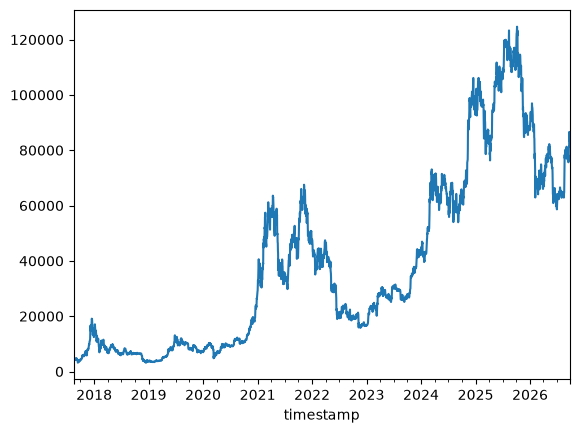

In [9]:
df_btc.close.plot()

### Q. 請將 df_btc 的開高低收頻率改成「每月」，其他 columns 可以刪除

In [10]:
df_btc.resample('ME').agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum',
})

,open,high,low,close,volume
timestamp,,,,,
2017-08-31 00:00:00+00:00,4261.48,4745.42,3400.00,4724.89,10015.640272
2017-09-30 00:00:00+00:00,4689.89,4939.19,2817.00,4378.51,27634.189120
2017-10-31 00:00:00+00:00,4378.49,6498.01,4110.00,6463.00,41626.388463
2017-11-30 00:00:00+00:00,6463.00,11300.03,5325.01,9838.96,108487.978119
2017-12-31 00:00:00+00:00,9837.00,19798.68,9380.00,13716.36,408476.658399
...,...,...,...,...,...
2026-05-31 00:00:00+00:00,76346.58,82850.00,72512.49,73674.39,425331.030390
2026-06-30 00:00:00+00:00,73674.39,74092.00,58115.01,58624.71,632661.435830
2026-07-31 00:00:00+00:00,58624.71,66956.15,57800.19,62887.88,496528.308040


### Q. 請繪製 BTC 的 100 天移動平均線

<Axes: xlabel='timestamp'>

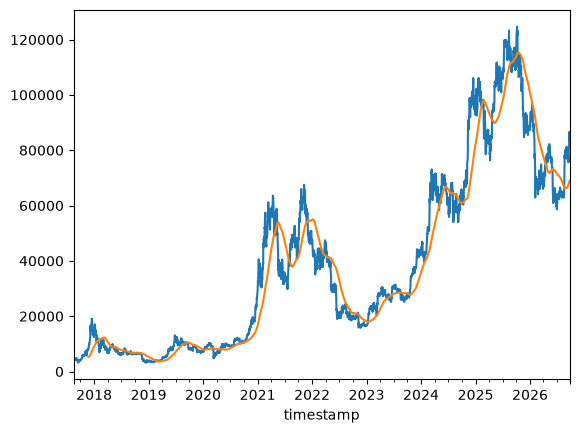

In [11]:
btc_mean = df_btc.close.rolling(100).mean()

df_btc.close.plot()
btc_mean.plot()

### Q. 請繪製 BTC 每年最後一天的收盤價折線圖

<Axes: xlabel='timestamp'>

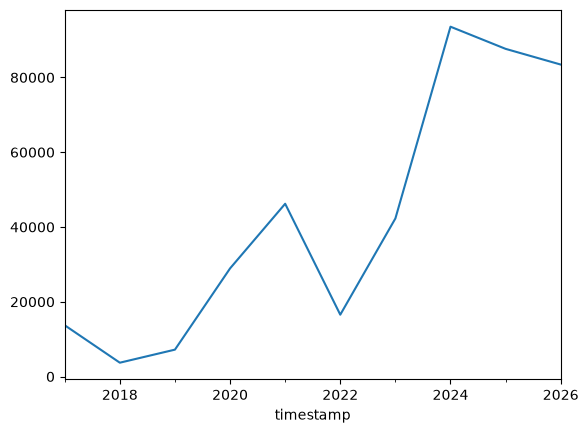

In [12]:
df_btc.close.resample('YE').last().plot()

### Q. 請計算 BTC 每年的平均價格

In [13]:
df_btc.close.resample('YE').mean()

timestamp
2017-12-31 00:00:00+00:00      7622.664015
2018-12-31 00:00:00+00:00      7538.113945
2019-12-31 00:00:00+00:00      7364.363205
2020-12-31 00:00:00+00:00     11110.548497
2021-12-31 00:00:00+00:00     47400.003041
2022-12-31 00:00:00+00:00     28185.217890
2023-12-31 00:00:00+00:00     28849.591781
2024-12-31 00:00:00+00:00     65963.592678
2025-12-31 00:00:00+00:00    101635.672822
2026-12-31 00:00:00+00:00     72881.647154
Freq: YE-DEC, Name: close, dtype: float64

### Q. 請計算並繪製 BTC 的 100 天標準差

<Axes: xlabel='timestamp'>

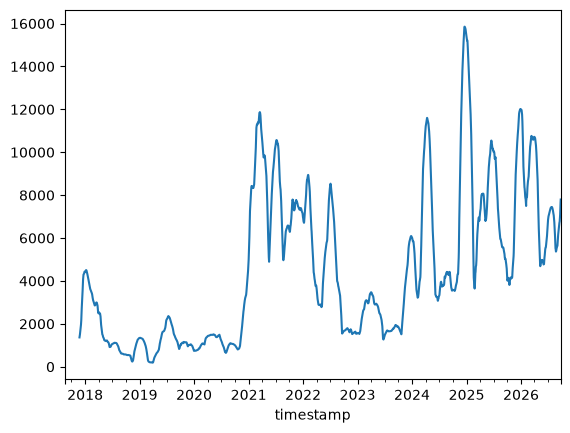

In [14]:
btc_std = df_btc.close.rolling(100).std()
btc_std.plot()

### Q. 請計算 BTC 的 100 日布林通道

<Axes: xlabel='timestamp'>

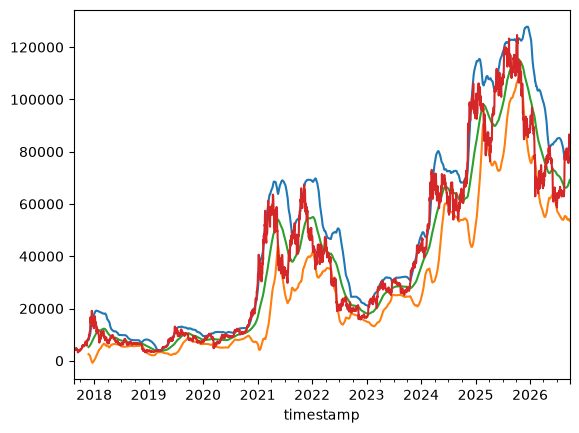

In [15]:
ub = btc_mean + 2 * btc_std
lb = btc_mean - 2 * btc_std

ub.plot()
lb.plot()
btc_mean.plot()
df_btc.close.plot()

### Q. BTC 收盤價大於 1 萬的資料，共有幾筆？

In [16]:
(df_btc.close > 10000).sum()

np.int64(2415)

### Q. BTC 在星期幾持有報酬率最高？（0 是星期一）

<Axes: xlabel='timestamp'>

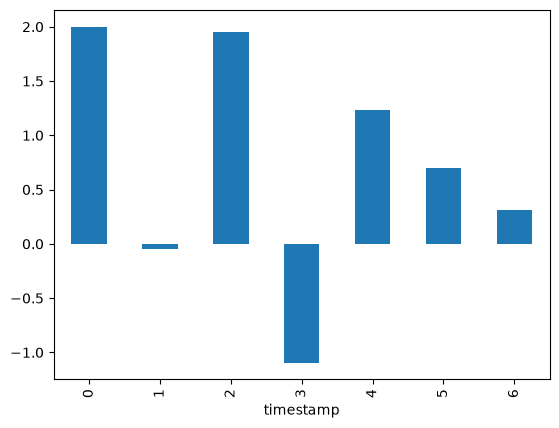

In [17]:
ret = df_btc.close / df_btc.open - 1
week_ret = ret.groupby(ret.index.weekday).sum()
week_ret.plot.bar()

### Q. BTC 上漲和下跌的天數？

In [18]:
(df_btc.close > df_btc.close.shift()).sum(), (df_btc.close < df_btc.close.shift()).sum()

(np.int64(1700), np.int64(1625))

### Q. BTC 最近 100 天上漲、下跌的天數？

In [19]:
(df_btc.close > df_btc.close.shift()).tail(100).sum(), (df_btc.close < df_btc.close.shift()).tail(100).sum()

(np.int64(52), np.int64(48))

### Q. BTC 近 100 日漲幅？

In [20]:
df_btc.close.iloc[-1] / df_btc.close.iloc[-101] - 1

np.float64(0.2706204384285591)

### Q. BTC 近 100 日最低價格？

In [21]:
df_btc.low.tail(100).min()

np.float64(57800.19)

### Q. BTC 近 100 日最高價格？

In [22]:
df_btc.high.tail(100).max()

np.float64(87395.67)

### Q. BTC 目前價格是否高於 100 日均價？

In [23]:
df_btc.close.iloc[-1] > df_btc.close.tail(100).mean()

np.True_

### Q. 請從 df 製作一個新表格 df_close：columns 為加密貨幣的名稱，index 為時間，數值為收盤價

In [24]:
df_close = df.pivot(index='timestamp', columns='name', values='close')
df_close

name,BNB,BTC,ETH
timestamp,,,
2017-08-17 00:00:00+00:00,NaN,4285.08,302.00
2017-08-18 00:00:00+00:00,NaN,4108.37,293.96
2017-08-19 00:00:00+00:00,NaN,4139.98,290.91
2017-08-20 00:00:00+00:00,NaN,4086.29,299.10
2017-08-21 00:00:00+00:00,NaN,4016.00,323.29
...,...,...,...
2026-09-20 00:00:00+00:00,772.56,81178.00,2645.21
2026-09-21 00:00:00+00:00,799.41,86620.00,2776.19
2026-09-22 00:00:00+00:00,788.38,86208.56,2753.63


### Q. 繪製這三種加密貨幣的收盤價於同一張圖上

<Axes: xlabel='timestamp'>

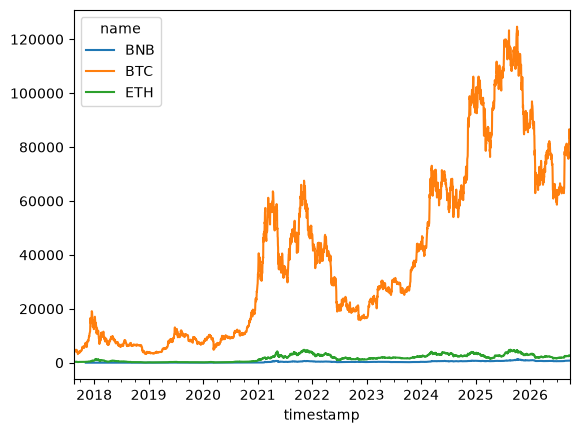

In [25]:
df_close.plot()

### Q. 繪製 BTC 與 ETH 於同一張圖表上（使用 secondary_y=True）

<Axes: >

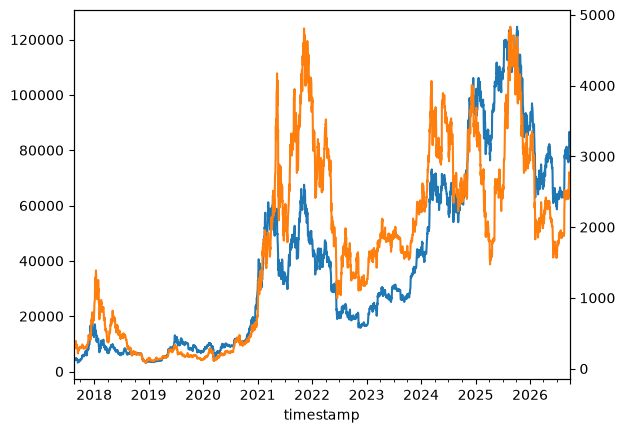

In [26]:
df_close.BTC.plot()
df_close.ETH.plot(secondary_y=True)

### Q. 繪製三種加密貨幣從 2018 年開始的累積報酬率折線圖

<Axes: xlabel='timestamp'>

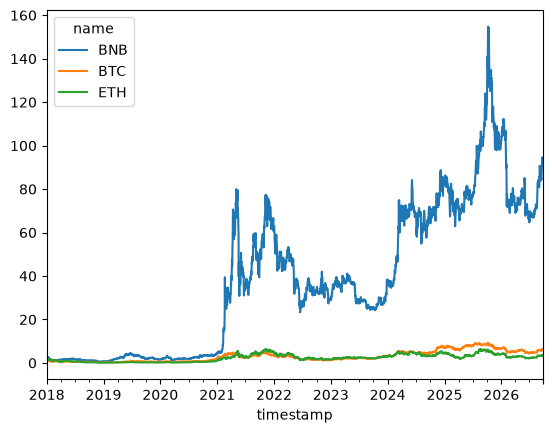

In [27]:
(df_close.loc['2018':].pct_change() + 1).cumprod().plot()

### Q. 比較三種加密貨幣的每年年報酬（以每年最後一天收盤價結算即可）

<Axes: xlabel='timestamp'>

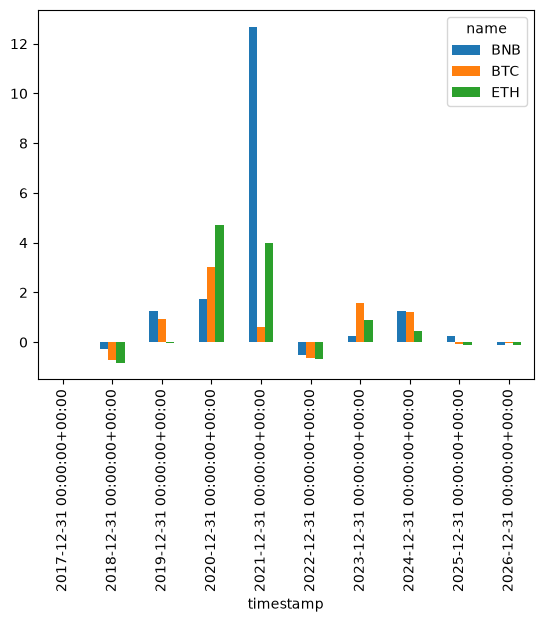

In [28]:
df_close.resample('YE').last().pct_change().plot.bar()